In [50]:
import numpy as np
import torch
import torch.optim as optim
from dataloaders import GetSingleStepDataLoaders
import model
from train import train_model

In [ ]:
batch_size = 32
output_folder = "./output_cogging/"
save_results = True
use_GPU = True
latent_size = 256
epochs = 200

In [60]:
data  = np.load('/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/data/test_comb_med_neg.npz')
c_t = data['coords_t']
c_tp1 = data['coords_tp1']
steps = data['steps']
positions = data['positions']
rotations = data['rotations']
actions = np.hstack((steps, positions, rotations))

In [61]:
actions = np.hstack((steps, positions, rotations))


In [62]:
print(c_t.shape)
print(c_tp1.shape)
print(actions.shape)

(19796, 2048, 3)
(19796, 2048, 3)
(19796, 8)


In [63]:
point_size = c_t.shape[1]

In [64]:
train_loader, test_loader = GetSingleStepDataLoaders(
    coords_t=c_t,       
    coords_tp1=c_tp1,
    actions=actions,
    batch_size=batch_size
)

In [65]:
net = model.PCTransitionModel(point_size, latent_size)

if(use_GPU):
    device = torch.device("cuda:0")
    if torch.cuda.device_count() > 1:
        net = torch.nn.DataParallel(net)
else:
    device = torch.device("cpu")

net = net.to(device)

optimizer = optim.Adam(net.parameters(), lr=0.0005)

KeyboardInterrupt: 

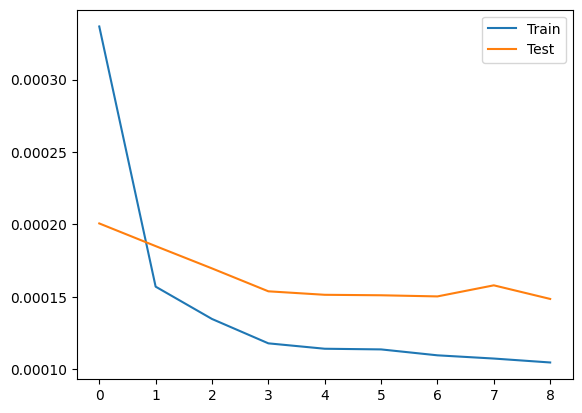

In [66]:
train_model(train_loader, test_loader, net, epochs, optimizer, device, save_results, output_folder)

In [ ]:
torch.save(net.state_dict(), './transition_model_comb__neg_2G.pth')